# TEST — Monthly (clmn) on polytope-test.mn5

Tests the new test server `polytope-test.mn5.apps.dte.destination-earth.eu`
with the monthly portfolio using `IFS-NEMO` and `2t`.

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [1]:
import logging, warnings
import earthkit.data

earthkit.data.config.set("cache-policy", "off")

for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
from polytope_zarr import PolytopeZarrStore

## 1. Create monthly store on test server

In [3]:
TEST_ADDRESS = "polytope-test.mn5.apps.dte.destination-earth.eu"

store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-NEMO"],
    experiment="hist",
    levtype="sfc",
    years=range(1990, 1992),
    address=TEST_ADDRESS,
)
print(store)

<PolytopeZarrStore 34 variables (time=24, cell=196608, model=1)>


In [4]:
ds = store.open()
ds

<xarray.Dataset> Size: 643MB
Dimensions:       (model: 1, time: 24, cell: 196608)
Coordinates:
  * model         (model) object 8B 'IFS-NEMO'
  * time          (time) datetime64[ns] 192B 1990-01-01 ... 1991-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 19MB ...
    avg_10v       (model, time, cell) float32 19MB ...
    avg_10ws      (model, time, cell) float32 19MB ...
    avg_2d        (model, time, cell) float32 19MB ...
    avg_2t        (model, time, cell) float32 19MB ...
    avg_ie        (model, time, cell) float32 19MB ...
    ...            ...
    avg_tnlwrcs   (model, time, cell) float32 19MB ...
    avg_tnlwrf    (model, time, cell) float32 19MB ...
    avg_tnswrf    (model, time, cell) float32 19MB ...
    avg_tnswrfcs  (model, time, cell) float32 19MB ...
    avg_tprate    (model, time, cell) float32 19MB ...
    avg_tsrwe     (model, time, cell) float32 19MB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=24, cell=196608, ...

## 2. Fetch a single field (lazy browse)

Fetching {'cell': 196608} values...
  ⚡ batching 12 time chunks for avg_2t


2026-04-01 18:37:01 - INFO - Key read from /Users/natr/.polytopeapirc
2026-04-01 18:37:01 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'month: 1/2/3/4/5/6/7/8/9/10/11/12\n'
            'param: avg_2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            "year: '1990'\n",
 'verb': 'retrieve'}
2026-04-01 18:37:01 - INFO - Polytope user key found in session cache for user natr
2026-04-01 18:37:03 - INFO - Request accepted. Please poll ./d4fc7c78-48e6-49c4-93c1-faa1d9e70a4c for status
2026-04-01 18:37:03 - INFO - Polytope user key found in session cache for user natr
2026-04-01 18:37:03 - INFO - Checking request status (d4fc7c78-48e6-49c4-93c1-faa1d9e70a4c)...
2

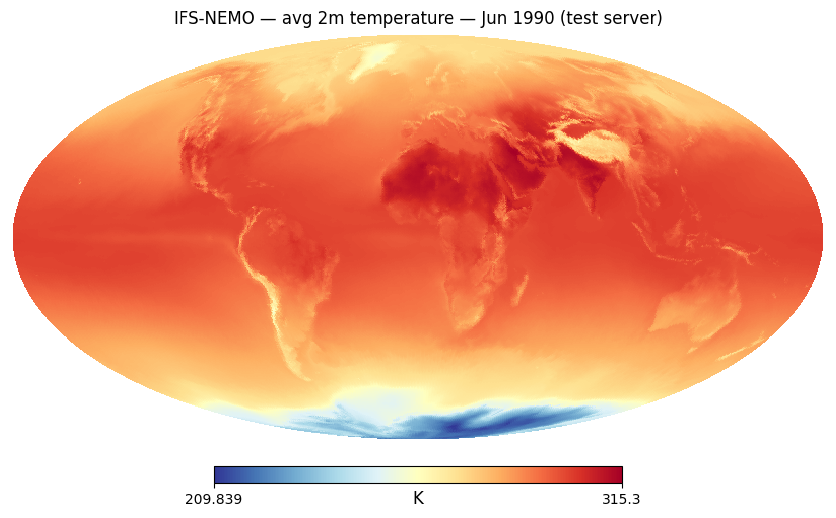

In [5]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["avg_2t"].sel(model="IFS-NEMO", time="1990-06-01")
print(f"Fetching {dict(field.sizes)} values...")

hp.mollview(field.values, title="IFS-NEMO — avg 2m temperature — Jun 1990 (test server)",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

## 3. Server-side area subsetting

In [6]:
area_ds = ds["avg_2t"].polytope.sel(
    model="IFS-NEMO",
    time="1990-06",
    area=(55, 5, 47, 15),
    #grid="0.25/0.25", # default for standard resolution
)
area_ds

  🌍 area request for avg_2t (1990-6, area=55/5/47/15, grid=0.25/0.25)


<xarray.Dataset> Size: 11kB
Dimensions:    (latitude: 33, longitude: 41)
Coordinates:
  * latitude   (latitude) float64 264B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * longitude  (longitude) float64 328B 5.0 5.25 5.5 5.75 ... 14.5 14.75 15.0
Data variables:
    avg_2t     (latitude, longitude) float64 11kB ...
Attributes:
    param:        avg_2t
    paramId:      228004
    class:        d1
    stream:       clmn
    levtype:      sfc
    type:         fc
    expver:       0001
    date:         19900601
    Conventions:  CF-1.8
    institution:  ECMWF

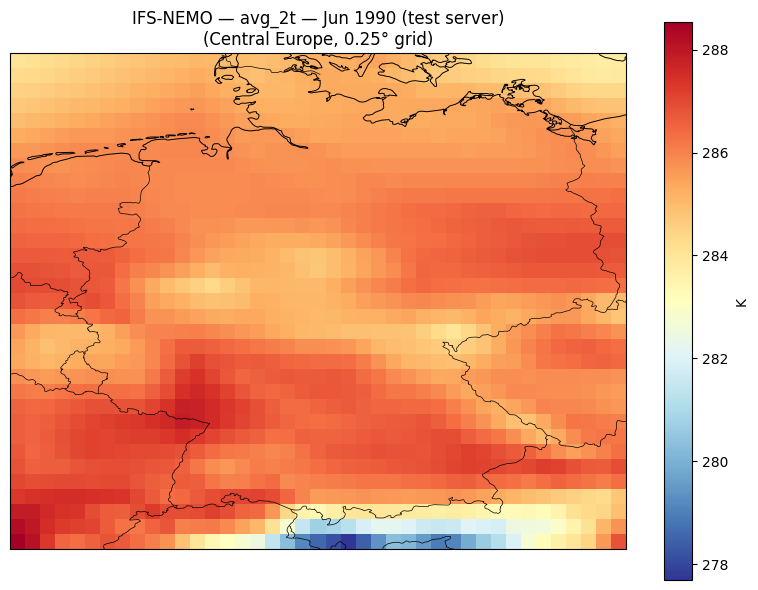

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

var_name = list(area_ds.data_vars)[0]
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8, 6))
area_ds[var_name].plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdYlBu_r",
                       cbar_kwargs={"label": "K"})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.set_title(f"IFS-NEMO — {var_name} — Jun 1990 (test server)\n(Central Europe, 0.25° grid)")
plt.tight_layout()
plt.show()

## 4. Feature extraction — timeseries (monthly)

Monthly timeseries uses `time_axis: "month"` and returns JSON.
This tests whether `polytope-test.mn5` has fixed the gribjump bug.

In [8]:
# Point timeseries — monthly (clmn stream)
ts_result = ds["avg_2t"].polytope.sel(
    model="IFS-NEMO",
    time=slice("1990-01", "1991-12"),
    point=(52.5, 13.4),  # Berlin
)
print(type(ts_result))
ts_result

  🌍 timeseries request for avg_2t (1990/to/1991-1/to/9)


<class 'dict'>


{'type': 'CoverageCollection',
 'domainType': 'PointSeries',
 'coverages': [{'mars:metadata': {'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'hist',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'ifs-nemo',
    'realization': 1,
    'resolution': 'standard',
    'stream': 'clmn',
    'type': 'fc',
    'number': 0,
    'levelist': 0},
   'type': 'Coverage',
   'domain': {'type': 'Domain',
    'axes': {'latitude': {'values': [52.416011889394]},
     'longitude': {'values': [13.811881188119]},
     'levelist': {'values': [0]},
     't': {'values': ['1990-01-01T00:00:00Z',
       '1990-02-01T00:00:00Z',
       '1990-03-01T00:00:00Z',
       '1990-04-01T00:00:00Z',
       '1990-05-01T00:00:00Z',
       '1990-06-01T00:00:00Z',
       '1990-07-01T00:00:00Z',
       '1990-08-01T00:00:00Z',
       '1990-09-01T00:00:00Z',
       '1991-01-01T00:00:00Z',
       '1991-02-01T00:00:00Z',
       '1991-03-01T00:00:00Z',
     

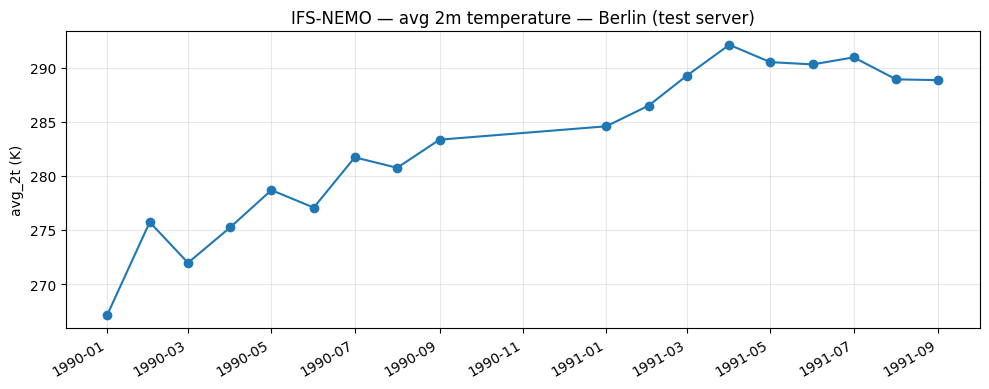

In [9]:
import pandas as pd

# Extract times and values from CoverageJSON
cov = ts_result["coverages"][0]
times = pd.to_datetime(cov["domain"]["axes"]["t"]["values"])
values = cov["ranges"]["avg_2t"]["values"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, marker="o")
ax.set_ylabel("avg_2t (K)")
ax.set_title("IFS-NEMO — avg 2m temperature — Berlin (test server)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Feature extraction — bounding box

In [10]:
# Bounding box — single month
bbox_result = ds["avg_2t"].polytope.sel(
    model="IFS-NEMO",
    time="1990-06",
    bbox=(47, 5, 55, 15),  # (south, west, north, east)
)
print(type(bbox_result))
bbox_result

  🌍 boundingbox request for avg_2t (1990-6)


<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 9kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 235)
Coordinates:
  * datetimes  (datetimes) <U20 80B '1990-06-01T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 2kB 0 1 2 3 4 5 6 ... 228 229 230 231 232 233 234
    latitude   (points) float64 2kB 47.36 47.36 47.36 ... 54.72 54.72 54.72
    longitude  (points) float64 2kB 13.82 13.03 7.5 6.711 ... 5.211 7.105 14.68
    levelist   (points) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (datetimes, number, steps, points) float64 2kB 282.4 ... 283.8
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  1990-06-01T00:00:00Z
    step:           0
    date:           1990-06-01T00:00:00Z

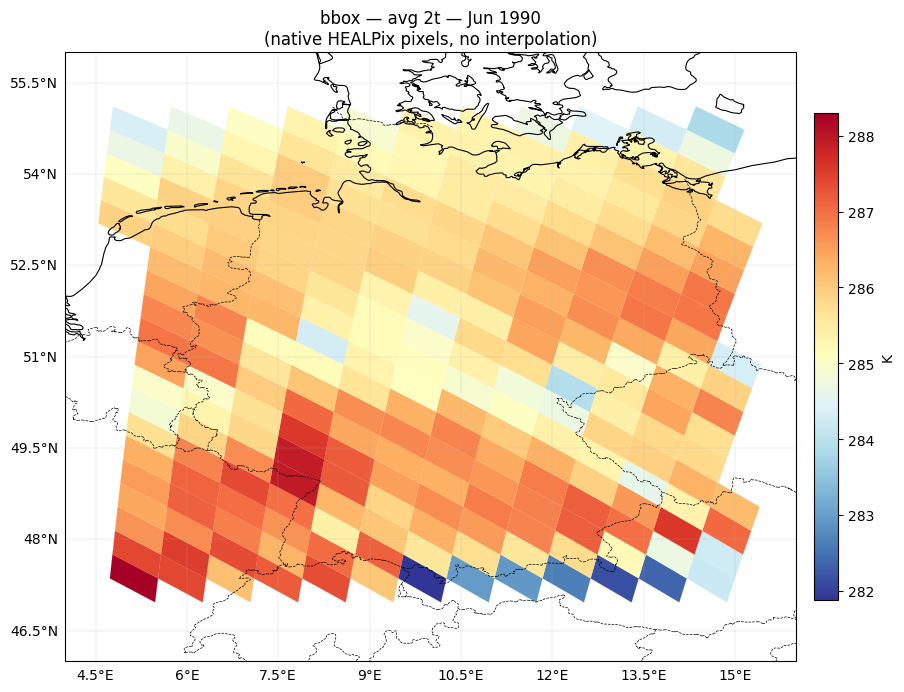

In [13]:
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors

nside = store.nside
da = bbox_result["avg_2t"].squeeze()
lats = bbox_result.coords["latitude"].values
lons = bbox_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

# Get pixel boundary vertices (returns 3×N×step arrays: x,y,z)
n_steps = 50  # smooth edges at standard resolution; decrease for higher res
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

# Convert boundary xyz → lon/lat and build polygon list
polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

# Plot with cartopy
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlBu_r

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(cmap)
coll.set_norm(norm)
ax.add_collection(coll)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([4, 16, 46, 56])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title("bbox — avg 2t — Jun 1990\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## 6. Feature extraction — polygon (country cut-out)

Uses `earthkit.geo.cartography.country_polygons()` to get the boundary
of any named country, then passes it to the Polytope polygon feature.
Returns native HEALPix cells inside the country shape — no interpolation.

In [17]:
import earthkit.geo.cartography

# Get country boundary from Natural Earth via earthkit-geo
COUNTRY = "Germany"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

poly_result = ds["avg_2t"].polytope.sel(
    model="IFS-NEMO",
    time="1990-06",
    polygon=shapes,
)
print(f"{COUNTRY}: {len(shapes)} sub-polygon(s), {sum(len(s) for s in shapes)} vertices total")
print(type(poly_result))
poly_result

  🌍 polygon request for avg_2t (1990-6)


Germany: 6 sub-polygon(s), 562 vertices total
<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 6kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 141)
Coordinates:
  * datetimes  (datetimes) <U20 80B '1990-06-01T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 1kB 0 1 2 3 4 5 6 ... 134 135 136 137 138 139 140
    latitude   (points) float64 1kB 47.75 47.75 47.75 ... 54.34 54.72 54.72
    longitude  (points) float64 1kB 7.566 8.363 9.159 9.956 ... 13.59 9.0 9.947
    levelist   (points) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    avg_2t     (datetimes, number, steps, points) float64 1kB 286.3 ... 285.4
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     2
    ...             ...
    stream:         clmn
    type:           fc
    number:         0
    Forecast date:  1990-06-01T00:00:00Z
    step:           0
    date:           1990-06-01T00:00:00Z

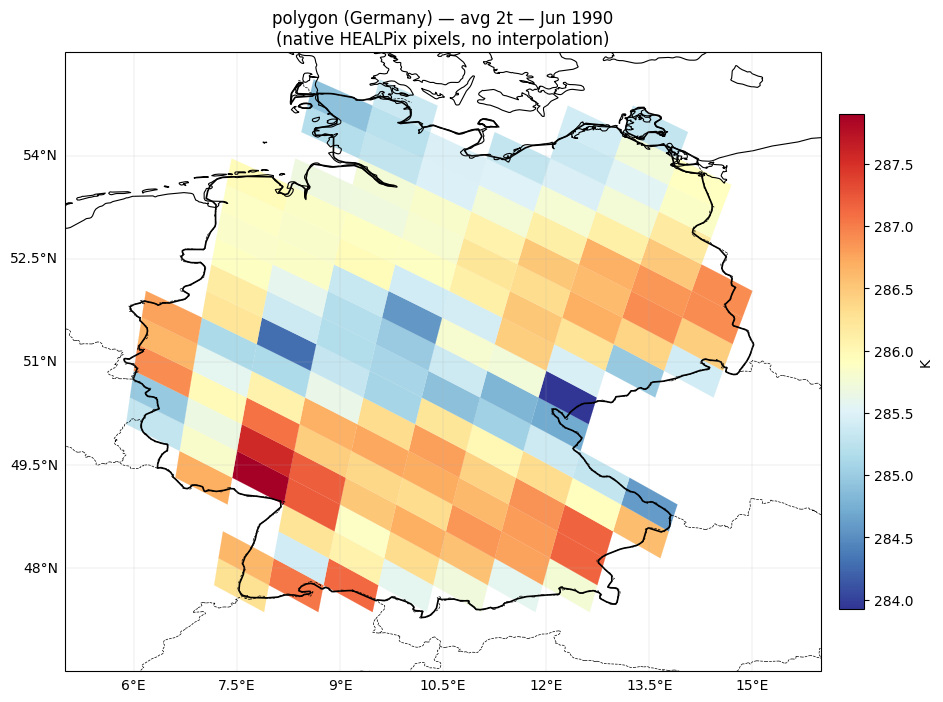

In [18]:
nside = store.nside
da = poly_result["avg_2t"].squeeze()
lats = poly_result.coords["latitude"].values
lons = poly_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(plt.cm.RdYlBu_r)
coll.set_norm(norm)
ax.add_collection(coll)

# Overlay country outline from earthkit-geo shapes
for shape in shapes:
    s_lons = [pt[1] for pt in shape]
    s_lats = [pt[0] for pt in shape]
    ax.plot(s_lons, s_lats, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 16, 46.5, 55.5])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title(f"polygon ({COUNTRY}) — avg 2t — Jun 1990\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

In [19]:
store.clear_cache()